In [1]:
!pip install fsspec s3fs

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 200 kB 15.5 MB/s            
     |████████████████████████████████| 87 kB 11.1 MB/s            
     |████████████████████████████████| 1.7 MB 79.6 MB/s            
     |████████████████████████████████| 14.3 MB 66.0 MB/s            
     |████████████████████████████████| 81 kB 16.0 MB/s            
     |████████████████████████████████| 240 kB 117.2 MB/s            
     |████████████████████████████████| 346 kB 101.2 MB/s            
     |████████████████████████████████| 197 kB 104.8 MB/s            
     |████████████████████████████████| 219 kB 118.4 MB/s            
     |████████████████████████████████| 44 kB 5.2 MB/s             
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
boto3 1.42.86 requires botocore<1.43.0,>=1.42.86, but y

In [2]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 20.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 122.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 150.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 120.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 22.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.9/321.9 kB 50.0 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
import json
import os
import boto3
import time

headers = {
    "Authorization": "Bearer STUDENT_TOKEN_2026"
}

#url_latest = "https://e6uw49pbah.execute-api.us-east-1.amazonaws.com/dev/weather/latest?station_id=GDN_01"
url_batch = "https://e6uw49pbah.execute-api.us-east-1.amazonaws.com/dev/weather/batch?station_id=GDN_01&limit=100"
#url_stations = "https://e6uw49pbah.execute-api.us-east-1.amazonaws.com/dev/weather/stations"
stations = ["GDN_01","GDN_02","GDY_01","SOP_01"]

all_data = []
for stacja in stations:
    url_batch = f"https://e6uw49pbah.execute-api.us-east-1.amazonaws.com/dev/weather/batch?station_id={stacja}&limit=100"
    response = requests.get(url_batch, headers=headers)
    
    if response.status_code == 200:
        data = response.json()
        print("Udało się pobrać dane")
        all_data.extend(data["records"])
        
    time.sleep(0.5)
        
s3 = boto3.client('s3')

BUCKET_NAME = 'aws-logs-003693136002-us-east-1' 

FILE_OUT = 'raw_data.json'
json_data_string = json.dumps(all_data, indent=4)

try:
    s3.put_object(
        Bucket=BUCKET_NAME,
        Key=FILE_OUT,
        Body=json_data_string,
        ContentType='application/json'
    )
    print(f"Plik został zapisany pod adresem: s3://{BUCKET_NAME}/{FILE_OUT}")
except Exception as e:
    print(e)
        

Udało się pobrać dane
Udało się pobrać dane
Udało się pobrać dane
Udało się pobrać dane
Plik został zapisany pod adresem: s3://aws-logs-003693136002-us-east-1/raw_data.json


In [4]:
import boto3
import pandas as pd
import json

BUCKET_NAME = 'aws-logs-003693136002-us-east-1'
FILE_IN = 'raw_data.json'
FILE_OUT = f's3://{BUCKET_NAME}/validated_data.csv'

s3 = boto3.client('s3')
response = s3.get_object(Bucket=BUCKET_NAME, Key=FILE_IN)    
file_content = response['Body'].read().decode('utf-8')
raw_data = json.loads(file_content)
    
df = pd.DataFrame(raw_data)
    
    
df['timestamp'] = pd.to_datetime(df['timestamp'])
    
print(df.isnull().sum())
df = df.dropna()
    
print("\nStatystyki dla wiatru i temperatury przed czyszczeniem:")
print(df[['wind_speed', 'temperature', 'humidity']].describe())
    
df_clean = df[
        (df['wind_speed'] >= 0) & 
        (df['humidity'] >= 0) & 
        (df['humidity'] <= 100)
]
try:
    df_clean.to_csv(FILE_OUT, index=False)
    print(f"Oczyszczone dane po walidacji zostały zapisane w S3: {FILE_OUT}")
except Exception as e:
    print(e)


timestamp         0
station_id        0
temperature       0
humidity          0
pressure          0
wind_speed        0
wind_direction    0
rain_mm           0
cloud_cover       0
dtype: int64

Statystyki dla wiatru i temperatury przed czyszczeniem:
       wind_speed  temperature    humidity
count  400.000000   400.000000  400.000000
mean     7.395425    17.047075   71.130700
std      4.049964     2.402072   14.500675
min      0.020000    12.550000   45.150000
25%      3.797500    15.037500   58.532500
50%      7.750000    16.890000   71.385000
75%     10.807500    18.915000   84.322500
max     13.980000    21.770000   94.650000
Oczyszczone dane po walidacji zostały zapisane w S3: s3://aws-logs-003693136002-us-east-1/validated_data.csv



Przyjęto 3 stopnie ryzyka oraz 3 aktywności: jazdę na rowerze, bieganie, praca terenowa

Zasady ryzyka

Jazda na rowerze:
- Wysokie ryzyko: średnie prędkości wiatru > 8 km/h lub maksymalna prędkość > 15 km/h
- Średnie ryzyko: średnie prędkości wiatru > 5 km/h
- Niskie ryzyko: pozostałe przypadki

Bieganie:
- Wysokie ryzyko: średnie prędkości wiatru > 10 km/h lub maksymalna prędkość > 20 km/h
- Średnie ryzyko: średnie prędkości wiatru > 6 km/h
- Niskie ryzyko: pozostałe przypadki

Praca terenowa:
- Wysokie ryzyko: średnie prędkości wiatru > 13 km/h lub maksymalna prędkość > 24 km/h
- Średnie ryzyko: średnie prędkości wiatru > 8 km/h
- Niskie ryzyko: pozostałe przypadki


,station_id,timestamp,wind_speed_mean,wind-risk_score,cycling_risk,running_risk,field_work_risk
0,GDN_01,2026-06-14 20:00:00+00:00,9.245000,3,Wysokie,Średnie,Średnie
1,GDN_01,2026-06-14 21:00:00+00:00,6.328333,2,Średnie,Średnie,Niskie
2,GDN_01,2026-06-14 22:00:00+00:00,7.428333,2,Średnie,Średnie,Niskie
3,GDN_01,2026-06-14 23:00:00+00:00,5.365000,2,Średnie,Niskie,Niskie
4,GDN_01,2026-06-15 00:00:00+00:00,8.851667,3,Wysokie,Średnie,Średnie


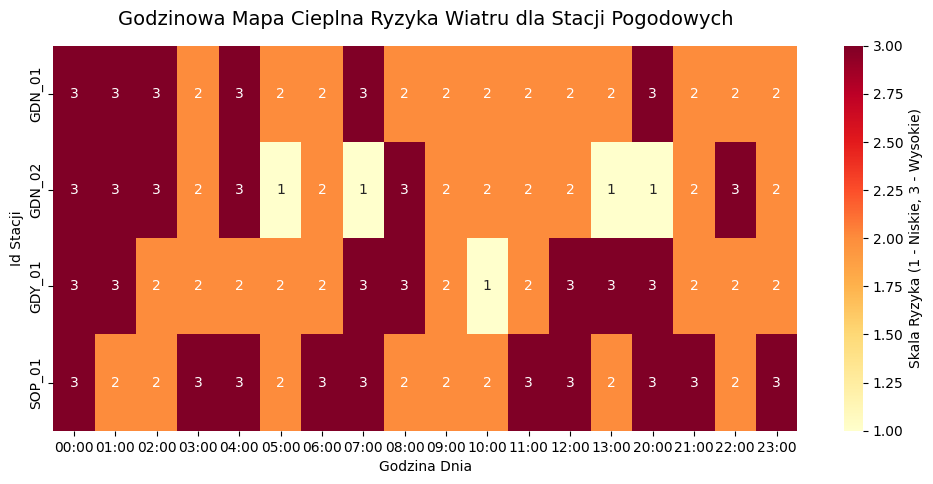

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

BUCKET_NAME = 'aws-logs-003693136002-us-east-1'
FILE_IN = f's3://{BUCKET_NAME}/validated_data.csv'

df_clean = pd.read_csv(FILE_IN)
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])

df_resampled = df_clean.set_index('timestamp')

df_hourly = df_resampled.groupby('station_id').resample('H').agg({
    'wind_speed': ['mean', 'max'],
    'temperature': 'mean',
    'humidity': 'mean',
    'pressure': 'mean',
    'rain_mm': 'sum',      
    'cloud_cover': 'mean'
})

df_hourly.columns = ['_'.join(col).strip() for col in df_hourly.columns.values]
df_hourly = df_hourly.reset_index()


def ocen_ryzyko(row):
    sredni_wiatr = row['wind_speed_mean']
    maks_wiatr = row['wind_speed_max']
    
    if sredni_wiatr > 8 or maks_wiatr > 15:
        cycling = 'Wysokie'
    elif sredni_wiatr > 5:
        cycling = 'Średnie'
    else:
        cycling = 'Niskie'
        
    if sredni_wiatr > 10 or maks_wiatr > 20:
        running = 'Wysokie'
    elif sredni_wiatr > 6:
        running = 'Średnie'
    else:
        running = 'Niskie'
        
    if sredni_wiatr > 13 or maks_wiatr > 24:
        field_work = 'Wysokie'
    elif sredni_wiatr > 8:
        field_work = 'Średnie'
    else:
        field_work = 'Niskie'
        
    if 'Wysokie' in [cycling, running, field_work]:
        risk_score = 3
    elif 'Średnie' in [cycling, running, field_work]:
        risk_score = 2
    else:
        risk_score = 1
        
    return pd.Series([risk_score, cycling, running, field_work], 
                     index=['wind-risk_score', 'cycling_risk', 'running_risk', 'field_work_risk'])

df_analiza = df_hourly.apply(ocen_ryzyko, axis=1)
df_final = pd.concat([df_hourly, df_analiza], axis=1)


print("\nPrzyjęto 3 stopnie ryzyka oraz 3 aktywności: jazdę na rowerze, bieganie, praca terenowa")
print("\nZasady ryzyka")
print("""\nJazda na rowerze:
- Wysokie ryzyko: średnie prędkości wiatru > 8 m/s lub maksymalna prędkość > 15 m/s
- Średnie ryzyko: średnie prędkości wiatru > 5 m/s
- Niskie ryzyko: pozostałe przypadki

Bieganie:
- Wysokie ryzyko: średnie prędkości wiatru > 10 m/s lub maksymalna prędkość > 20 m/s
- Średnie ryzyko: średnie prędkości wiatru > 6 m/s
- Niskie ryzyko: pozostałe przypadki

Praca terenowa:
- Wysokie ryzyko: średnie prędkości wiatru > 13 m/s lub maksymalna prędkość > 24 m/s
- Średnie ryzyko: średnie prędkości wiatru > 8 m/s
- Niskie ryzyko: pozostałe przypadki""")
display(df_final[['station_id', 'timestamp', 'wind_speed_mean', 'wind-risk_score', 'cycling_risk', 'running_risk','field_work_risk']].head())


df_final['godzina'] = df_final['timestamp'].dt.strftime('%H:%M')

macierz_ryzyka = df_final.pivot(index='station_id', columns='godzina', values='wind-risk_score')

plt.figure(figsize=(12, 5))
sns.heatmap(macierz_ryzyka, annot=True, cmap='YlOrRd', vmin=1, vmax=3, 
            cbar_kws={'label': 'Skala Ryzyka (1 - Niskie, 3 - Wysokie)'})

plt.title('Godzinowa Mapa Cieplna Ryzyka Wiatru dla Stacji Pogodowych', fontsize=14, pad=15)
plt.ylabel('Id Stacji')
plt.xlabel('Godzina Dnia')
plt.show()